## Building a regularised regression model 
Your task is to explore this synthetic telecom churn dataset to predict the mobile data usage of the customers. It is a simple dataset that allows you to explore the newly learnt ML skills.

### Churn dataset description 
The dataset contains information about telecommunications customer churn behaviour. It is a fictional telco company that provided mobile phone and internet services and the data is synthetic.   
It contains approximately 4000 records, each representing a customer, and contains a total of 8 variables/ features. These variables cover a variety of aspects related to the customer behaviour, demographic and contract types.

In [1]:
### loading packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import RandomizedSearchCV

from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.linear_model import ElasticNet

from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,accuracy_score

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

import datetime

In [2]:
## Read in comma separated file 

df = pd.read_csv('./churn_data.csv',index_col = [0])

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   prev_month_usage  3813 non-null   float64
 1   tenure            4000 non-null   float64
 2   contract_type     4000 non-null   object 
 3   dob               4000 non-null   object 
 4   country           4000 non-null   object 
 5   paperless         4000 non-null   int64  
 6   mob_data          3999 non-null   float64
 7   churn             4000 non-null   int64  
dtypes: float64(3), int64(2), object(3)
memory usage: 281.2+ KB


In [4]:
df.head()

,prev_month_usage,tenure,contract_type,dob,country,paperless,mob_data,churn
0,NaN,17.0,Fixed Contract,03 August 1978,England,1,3.6708,1
1,1.278289,17.0,Fixed Contract,27 November 1972,Wales,0,1.4776,0
2,5.044904,14.0,Fixed Contract,09 December 1981,England,1,5.0345,1
3,NaN,21.0,Rolling Contract,31 May 1992,Wales,1,11.3131,1
4,3.384626,23.0,Fixed Contract,28 December 1976,Scotland,1,2.6148,0


### Data cleaning

In [5]:
def clean(df):
    ## Removing missing values 
    df.dropna(inplace=True)
    
    # Changing categorical variables value 
    df['contract_type'] = df['contract_type'].str.replace('rolling contract','Rolling Contract')
    df['contract_type'] = df['contract_type'].str.replace('Fixed-contract','Fixed Contract')
    
    # Assuming your DataFrame is called df and the birth date column is 'birth_date'
    df['dob'] = pd.to_datetime(df['dob'], dayfirst = True)
    current_date = datetime.datetime.now()
    ##df['age'] = (current_date - df['dob']).astype('<m8[Y]') a classic "Pandas evolution" snag.
    
    df['age'] = (current_date - df['dob']).dt.days // 365.25
    
    return df

In [6]:
df = clean(df)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3812 entries, 1 to 3999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   prev_month_usage  3812 non-null   float64       
 1   tenure            3812 non-null   float64       
 2   contract_type     3812 non-null   object        
 3   dob               3812 non-null   datetime64[ns]
 4   country           3812 non-null   object        
 5   paperless         3812 non-null   int64         
 6   mob_data          3812 non-null   float64       
 7   churn             3812 non-null   int64         
 8   age               3812 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int64(2), object(2)
memory usage: 297.8+ KB


### Model training

In [7]:
# Extract the predictors and target 

X = df.drop(columns = ['mob_data', 'dob']) # dropping target variable and unnecessary 
y = df['mob_data']

In [8]:
# Train Test Split 
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=456)

In [9]:
# Checking input sample size are correct
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (3049, 7)
y_train shape: (3049,)
X_test shape: (763, 7)
y_test shape: (763,)


In [10]:
# One-hot encoding on predictive features 
## One-hot encoding on categorical columsn before training the model 
X_train_encoded = pd.get_dummies(X_train, columns=['contract_type','country'], drop_first =True)
X_test_encoded = pd.get_dummies(X_test, columns=['contract_type', 'country'],drop_first =True)

In [11]:
## Setting global parameters

parameters = {'alpha':np.arange(0.1, 5, .1)} # start, stop, step
# for lasso and ridge

In [12]:
## Fitting the LASSO model and making predictions

model = Lasso(random_state = 4, max_iter=20000) # The hyperparameter alpha will be adjusted in the gridsearch
# Define the cross-validation scheme using Repeated K-Fold
cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1) # This will create multiple (n_splits * n_repeats) splits for more robust model evaluation


clf = GridSearchCV(model, parameters, cv = cv, n_jobs=1, scoring = 'neg_root_mean_squared_error',verbose=3)
# remember parameters is set above as a global parameter
# Scoring is set to 'neg_root_mean_squared_error' to evaluate RMSE (lower is better)
# verbose=3 will print detailed messages about the progress

# Fit the model on the training data
clf.fit(X=X_train_encoded, y=y_train)
lasso_model = clf.best_estimator_  # Retrieve the best estimator (best alpha value found by grid search)

print('The best alpha value is {}'.format(clf.best_params_['alpha']))

# Use the best Lasso model to make predictions on the test set
y_pred = lasso_model.predict(X_test_encoded)

Fitting 30 folds for each of 49 candidates, totalling 1470 fits
[CV 1/30] END .......................alpha=0.1;, score=-1.021 total time=   0.0s
[CV 2/30] END .......................alpha=0.1;, score=-1.007 total time=   0.0s
[CV 3/30] END .......................alpha=0.1;, score=-0.992 total time=   0.0s
[CV 4/30] END .......................alpha=0.1;, score=-0.945 total time=   0.0s
[CV 5/30] END .......................alpha=0.1;, score=-0.918 total time=   0.0s
[CV 6/30] END .......................alpha=0.1;, score=-0.940 total time=   0.0s
[CV 7/30] END .......................alpha=0.1;, score=-1.044 total time=   0.0s
[CV 8/30] END .......................alpha=0.1;, score=-0.935 total time=   0.0s
[CV 9/30] END .......................alpha=0.1;, score=-0.914 total time=   0.0s
[CV 10/30] END ......................alpha=0.1;, score=-0.847 total time=   0.0s
[CV 11/30] END ......................alpha=0.1;, score=-0.983 total time=   0.0s
[CV 12/30] END ......................alpha=0.

In [13]:
# First let's have a function that allows you to print the performance metric

def get_reg_results(truth, prediction, df, idx):
    '''
    This function generates a results dataframe given your y_test and predictions. 
    It allows you to take the output of this function and put it into the next time you call the function
    Filling out the entirity of the dataframe one function call (and row) at a time
    Inputs:
    - truth = y_test, the actual values
    - prediction = your predictions
    - df = a dataframe that is already set up to hold our data. 
    - idx = the method that you are using (which corresponds to a row index)
    Output:
    - the input df, but with another row filled out
    '''
    
    mse_int = mean_squared_error(y_test, y_pred)
    mse = round(mse_int, 3)
    rmse = round((mse_int)**0.5, 3)
    mae = round(mean_absolute_error(y_test, y_pred), 3)
    
    SS_Residual = sum((truth-prediction)**2)       
    SS_Total = sum((truth-np.mean(truth))**2)     
    r_squared = 1 - (float(SS_Residual))/SS_Total
    
    r2 = round(r_squared, 3)
    
    df.loc[idx, :] = [rmse, mae, r2]
    
    return df

In [14]:
results_reg = pd.DataFrame(index = ['Lasso', 'Ridge'], columns = ['RMSE', 'MAE', 'R2'])

results_reg = get_reg_results(y_test, y_pred, results_reg, 'Lasso')
results_reg

,RMSE,MAE,R2
Lasso,0.913,0.723,0.95
Ridge,NaN,NaN,NaN


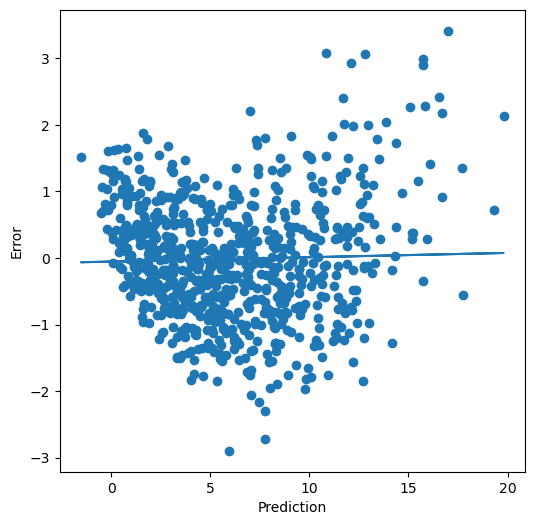

In [15]:
a, b = np.polyfit(lasso_model.predict(X_test_encoded), (y_test-lasso_model.predict(X_test_encoded)), 1)
fig,ax= plt.subplots(1, 1, figsize=(6, 6))
ax.scatter(lasso_model.predict(X_test_encoded),(y_test-lasso_model.predict(X_test_encoded)))
ax.set_xlabel("Prediction")
ax.set_ylabel("Error")
ax.plot(lasso_model.predict(X_test_encoded), a*lasso_model.predict(X_test_encoded)+b)

In [18]:
## Fitting the Ridge model and making predictions

model = Ridge(random_state = 4) #alpha will be adjusted in the gridsearch
cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)

clf = GridSearchCV(model, parameters, cv = cv, n_jobs=1, scoring = 'neg_root_mean_squared_error')
# remember parameters is set above as a global parameter

clf.fit(X=X_train_encoded, y=y_train)
ridge_model = clf.best_estimator_

print('The best alpha value is {}'.format(clf.best_params_['alpha']))

y_pred = ridge_model.predict(X_test_encoded)


The best alpha value is 4.9


In [19]:
results_reg = get_reg_results(y_test, y_pred, results_reg, 'Ridge')
results_reg

,RMSE,MAE,R2
Lasso,0.913,0.723,0.95
Ridge,0.904,0.716,0.951


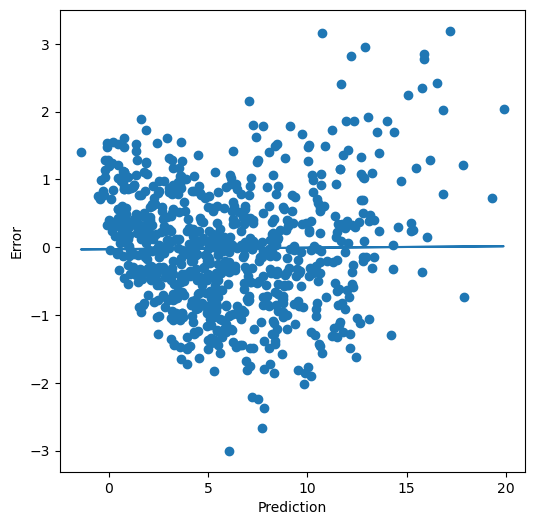

In [20]:
a, b = np.polyfit(ridge_model.predict(X_test_encoded), (y_test-ridge_model.predict(X_test_encoded)), 1)
fig,ax= plt.subplots(1, 1, figsize=(6, 6))
ax.scatter(ridge_model.predict(X_test_encoded),(y_test-ridge_model.predict(X_test_encoded)))
ax.set_xlabel("Prediction")
ax.set_ylabel("Error")
ax.plot(ridge_model.predict(X_test_encoded), a*ridge_model.predict(X_test_encoded)+b)

In [21]:
lasso_df = pd.DataFrame({'variable': list(X_train_encoded.columns), 'estimate': lasso_model.coef_})
lasso_df = lasso_df.sort_values('estimate')
lasso_df

,variable,estimate
4,age,-0.173226
3,churn,0.000000
5,contract_type_Rolling Contract,0.000000
2,paperless,0.000000
6,country_NI,-0.000000
7,country_Scotland,0.000000
8,country_Wales,-0.000000
1,tenure,0.010460
0,prev_month_usage,0.553810


In [22]:
lasso_df = lasso_df[lasso_df['estimate'] != 0]
lasso_df

,variable,estimate
4,age,-0.173226
1,tenure,0.010460
0,prev_month_usage,0.553810


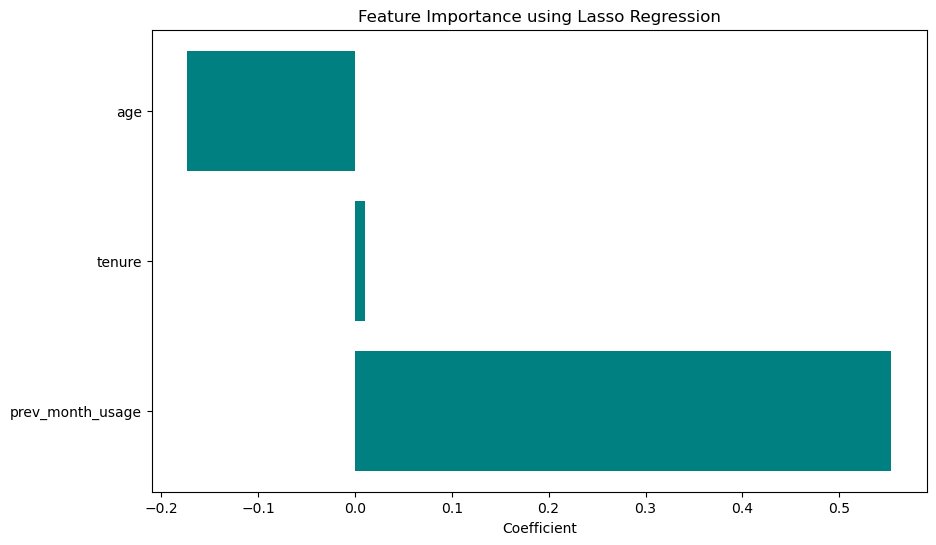

In [23]:
# Plot the feature importance
plt.figure(figsize=(10, 6))
plt.barh(lasso_df['variable'], lasso_df['estimate'], color='teal')
plt.xlabel('Coefficient')
plt.title('Feature Importance using Lasso Regression')
plt.gca().invert_yaxis()  # To display the most important feature at the top
plt.show()

In [24]:
ridge_df = pd.DataFrame({'variable': list(X_train_encoded.columns), 'estimate': ridge_model.coef_})
ridge_df = ridge_df.sort_values('estimate')
ridge_df

,variable,estimate
4,age,-0.167249
8,country_Wales,-0.120192
6,country_NI,-0.032338
7,country_Scotland,-0.022412
1,tenure,0.013933
5,contract_type_Rolling Contract,0.059493
3,churn,0.063359
2,paperless,0.131598
0,prev_month_usage,0.570182


In [25]:
ridge_df.estimate = ridge_df.estimate.abs()
ridge_df = ridge_df.sort_values(by='estimate', ascending=False)
ridge_df

,variable,estimate
0,prev_month_usage,0.570182
4,age,0.167249
2,paperless,0.131598
8,country_Wales,0.120192
3,churn,0.063359
5,contract_type_Rolling Contract,0.059493
6,country_NI,0.032338
7,country_Scotland,0.022412
1,tenure,0.013933


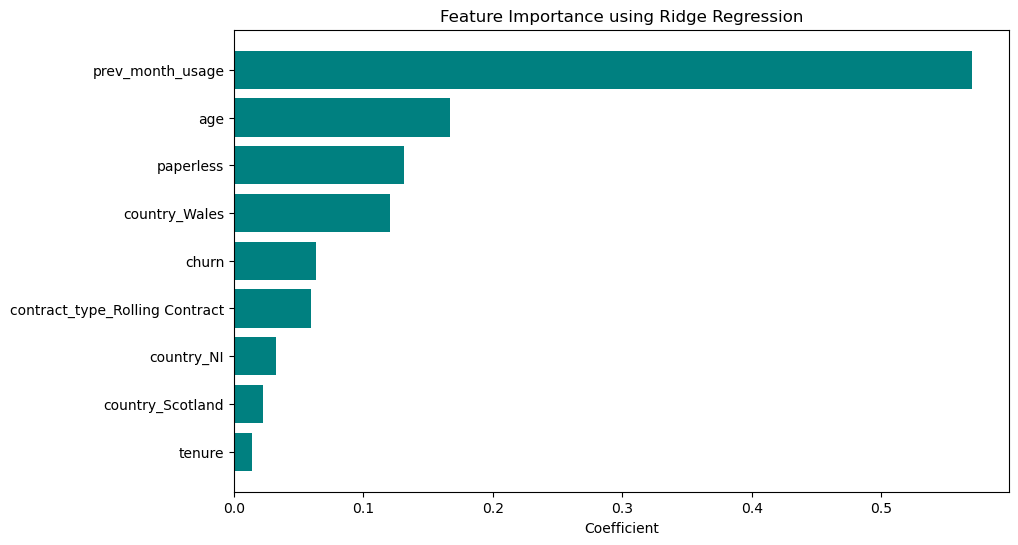

In [26]:
# Plot the feature importance
plt.figure(figsize=(10, 6))
plt.barh(ridge_df['variable'], ridge_df['estimate'], color='teal')
plt.xlabel('Coefficient')
plt.title('Feature Importance using Ridge Regression')
plt.gca().invert_yaxis()  # To display the most important feature at the top
plt.show()